# Quantitative Validation of single object Masks
This notebook intends to provide a Quantitative Validation of single object Masks. 
For this,  we align GRIDGENE-generated cell masks with IMC reference images. To note, cell based approaches are more relevant in CosMx data. However, IF data does not provide enough markers to function as reference. 

In [1]:
%load_ext autoreload
%autoreload 2

import os 
import sys
import time
import logging
import re
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from natsort import natsorted
import json

import cv2
import numpy as np
from PIL import Image
import tifffile as tiff
import copy 
import random
from natsort import natsorted
import sys
from pathlib import Path
import re
from shapely.geometry import Polygon

# Add GRIDGENE root to path
# You need to go up 2 levels
gridgene_root = Path.cwd().parent.parent  # analyses/quantification -> analyses -> GRIDGENE
sys.path.insert(0, str(gridgene_root))

print(f"Added to path: {gridgene_root}")
print(f"gridgene package location: {gridgene_root / 'gridgene'}")
from gridgene import get_arrays as ga
from gridgene import contours 
from gridgene import get_masks
      
      

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile
import cv2
from tqdm import tqdm

# Add GRIDGENE to path
gridgene_root = Path.cwd().parent.parent
sys.path.insert(0, str(gridgene_root))

# Import GRIDGENE modules
from gridgene import get_arrays as ga
from gridgene import contours, get_masks

# Import quantification modules
sys.path.append(str(Path.cwd().parent / 'scripts'))
from scripts.preprocessing import preprocess_if_image, register_masks_to_image
from scripts.metrics import calculate_overlap_metrics, calculate_enrichment

print("✓ Imports successful")
print(f"Working directory: {Path.cwd()}")
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from matplotlib.patches import Patch
import tifffile
import os
from natsort import natsorted
import copy
      
from scipy import ndimage
from skimage import morphology
import numpy as np
import matplotlib.pyplot as plt

from skimage import morphology
import cv2
      
import sys
sys.path.append('/home/martinha/PycharmProjects/phd/Preprocess_IMC')

import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import morphology
import tifffile

from src.file_specs import FileSpecifics
import src.ImageParser as IP
from pathlib import Path
import tifffile
import numpy as np
from scipy import ndimage
from skimage import morphology
import numpy as np
import tifffile
import matplotlib.pyplot as plt

import os
from pathlib import Path
import pandas as pd

Added to path: /home/martinha/PycharmProjects/phd/GRIDGENE
gridgene package location: /home/martinha/PycharmProjects/phd/GRIDGENE/gridgene
✓ Imports successful
Working directory: /home/martinha/PycharmProjects/phd/GRIDGENE/analyses/quantitative_validation


In [2]:
# define the logger :  can be None, and is set to INFO
# Custom logger setup
logger = logging.getLogger('contour_logger')
handler = logging.StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)
logger.setLevel(logging.INFO)

***Quantitative analysis for γδ cells*** 
We will now do the same quantitative analysis but this time with Xenium data. Importantly we only have 3 cores matching Imaging Mass Cytometry (IMC) experiments. We will 
    - (1) Run gridgene pipeline on Xenium;
    - (2) Fetch IMC correspondending images
    - (3) Analyse the overlay between gridgene and IMC masks. 
    
Importantly, the overlay between both images would depend on the parametes used both in gridgen and the preprocessing of IF, meaning, depending on the degree of details, mas can become more smooth or more fine grained.

Define Paths

In [3]:
# ============================================================================
# XENIUM + IMC CONFIGURATION
# ============================================================================

# Base paths
xenium_base_path = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium_data/HLA/GD_TMA1_S3/fov_filtered'
imc_base_path = "/home/martinha/PycharmProjects/phd/spatial_transcriptomics/GRIDGEN/case_studies/PENGUINcompositesIMC"
# imc_base_path = "/home/martinha/PycharmProjects/phd/spatial_transcriptomics/GRIDGEN/xenium_imc_data"
baysor_base_path_xenium = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium/HLA_analysis/cell_segmentation/cells_prior07'

# Shared files (same for all ROIs)
phenotype_h5ad_path = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium/HLA_analysis/cell_prior07_v20_03.h5ad'
selection_coords_path = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium_data/HLA/GD_TMA1_S3/coordinates_HLA1.csv'

# ROI to Selection mapping
roi_to_selection = {
    'ROI001': 'Selection8',
    'ROI002': 'Selection32',
    'ROI003': 'Selection13'
}

# Build the ROI data dictionary
roi_data = {
    'ROI001': {
        'xenium_path': os.path.join(xenium_base_path, 'TMA1_Selection8_filtered.csv'),
        'imc_path': os.path.join(imc_base_path, 'ROI001_ROI_001.ome.tiff'),
        'baysor_folder': os.path.join(baysor_base_path_xenium, 'TMA1_Selection8'),
        'baysor_json': os.path.join(baysor_base_path_xenium, 'TMA1_Selection8', 'segmentation_polygons.json'),
        'selection_name': 'Selection8'
    },
    'ROI002': {
        'xenium_path': os.path.join(xenium_base_path, 'TMA1_Selection32_filtered.csv'),
        'imc_path': os.path.join(imc_base_path, 'ROI002_ROI_002.ome.tiff'),
        'baysor_folder': os.path.join(baysor_base_path_xenium, 'TMA1_Selection32'),
        'baysor_json': os.path.join(baysor_base_path_xenium, 'TMA1_Selection32', 'segmentation_polygons.json'),
        'selection_name': 'Selection32'
    },
    'ROI003': {
        'xenium_path': os.path.join(xenium_base_path, 'TMA1_Selection13_filtered.csv'),
        'imc_path': os.path.join(imc_base_path, 'ROI003_ROI_003.ome.tiff'),
        'baysor_folder': os.path.join(baysor_base_path_xenium, 'TMA1_Selection13'),
        'baysor_json': os.path.join(baysor_base_path_xenium, 'TMA1_Selection13', 'segmentation_polygons.json'),
        'selection_name': 'Selection13'
    }
}

### 1. Imaging Mass cytometry images - IMC
Lets open the IMC images to check how they are. IMC images have 40+ markers and were preprocessed using PENGUIN. 

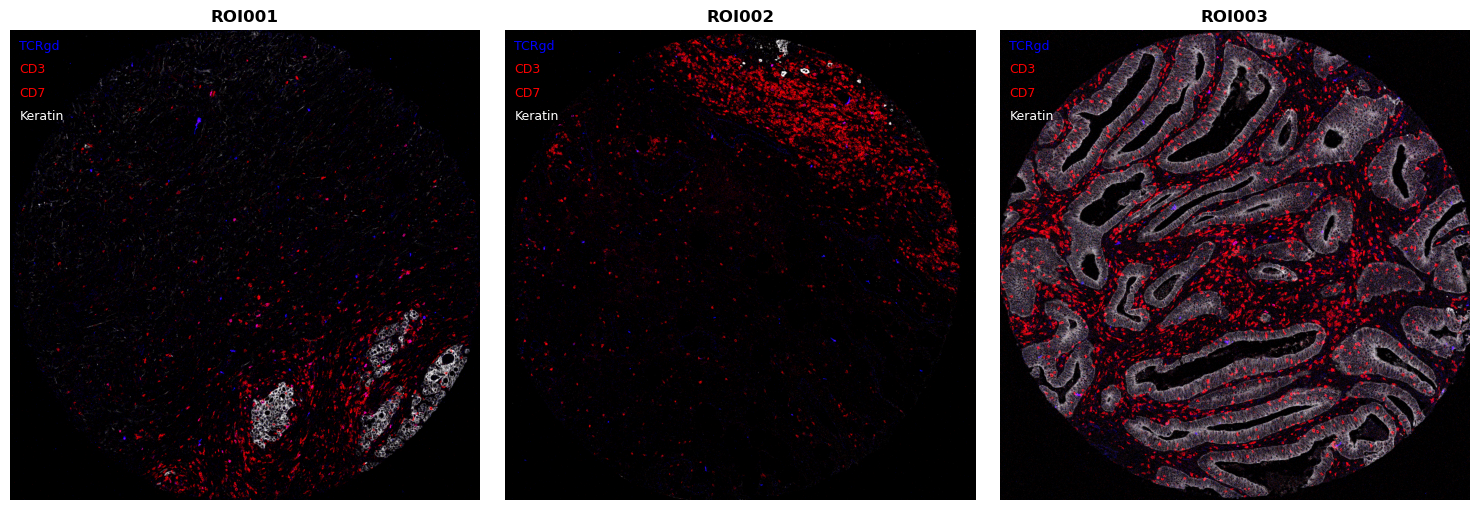

In [6]:
def load_imc_image(path):
    img = tifffile.imread(path)
    # Normalize to 0-255
    img = (img / 65535 * 255).astype(np.uint8)
    return img

imc_files = {
    'ROI001': 'ROI_001_BlueTCRgd_RedCD3_RedCD7_WhiteKeratin.tiff',
    'ROI002': 'ROI_002_BlueTCRgd_RedCD3_RedCD7_WhiteKeratin.tiff',
    'ROI003': 'ROI_003_BlueTCRgd_RedCD3_RedCD7_WhiteKeratin.tiff',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (roi_name, filename) in enumerate(imc_files.items()):
    img = load_imc_image(os.path.join(imc_path, filename))
    axes[idx].imshow(img)
    axes[idx].set_title(roi_name, fontweight='bold')
    # Add channel labels
    axes[idx].text(0.02, 0.98, 'TCRgd', color='blue',   transform=axes[idx].transAxes, fontsize=9, va='top')
    axes[idx].text(0.02, 0.93, 'CD3',   color='red',    transform=axes[idx].transAxes, fontsize=9, va='top')
    axes[idx].text(0.02, 0.88, 'CD7',   color='red',    transform=axes[idx].transAxes, fontsize=9, va='top')
    axes[idx].text(0.02, 0.83, 'Keratin', color='white', transform=axes[idx].transAxes, fontsize=9, va='top')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 2. Define Gridgene masks 

Define masks for γδ T cellls, CD8 T cells and fibroblasts? 

In [8]:
# add tumour for reference


Processing ROI001...
  Image dimensions: 1746 x 1651
  Total transcripts: 2902610


2026-03-14 12:48:43,865 - gridgene.contours.tum - INFO - Initialized GetContour
2026-03-14 12:48:43,918 - gridgene.contours.tum - INFO - get_conv_sum took 0.0521 seconds
2026-03-14 12:48:43,964 - gridgene.contours.tum - INFO - Number of contours after filtering no counts: 14
2026-03-14 12:48:43,964 - gridgene.contours.tum - INFO - contours_from_sum took 0.0461 seconds
2026-03-14 12:48:43,964 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks


  GD transcripts: 1909
  GD array sum: 1904.0
  AB transcripts: 4949


2026-03-14 12:48:44,620 - contour_logger - INFO - Initialized GetContour
2026-03-14 12:48:44,684 - contour_logger - INFO - get_conv_sum took 0.0634 seconds
2026-03-14 12:48:44,733 - contour_logger - INFO - Number of contours after filtering no counts: 124
2026-03-14 12:48:44,733 - contour_logger - INFO - contours_from_sum took 0.0487 seconds


  CD8 transcripts: 1481
  CD8 array sum: 1467.0

  Processing GD contours...
    Contours after density threshold: 124


...

    Contours after TRAC>=1 filter: 35
    Contours after TRBC>=1 filter: 24


2026-03-14 12:48:47,730 - contour_logger - INFO - Excluding contour 7. ab count 2.00 ≤ gd count 4.00
2026-03-14 12:48:47,862 - contour_logger - INFO - Contours remaining after gene comparison: 23


    Contours after ab>gd filter: 23


2026-03-14 12:48:48,087 - contour_logger - INFO - Contours remaining after gene comparison: 23
2026-03-14 12:48:48,088 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks
2026-03-14 12:48:48,089 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.
2026-03-14 12:48:48,089 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.


    Final CD8 contours: 23


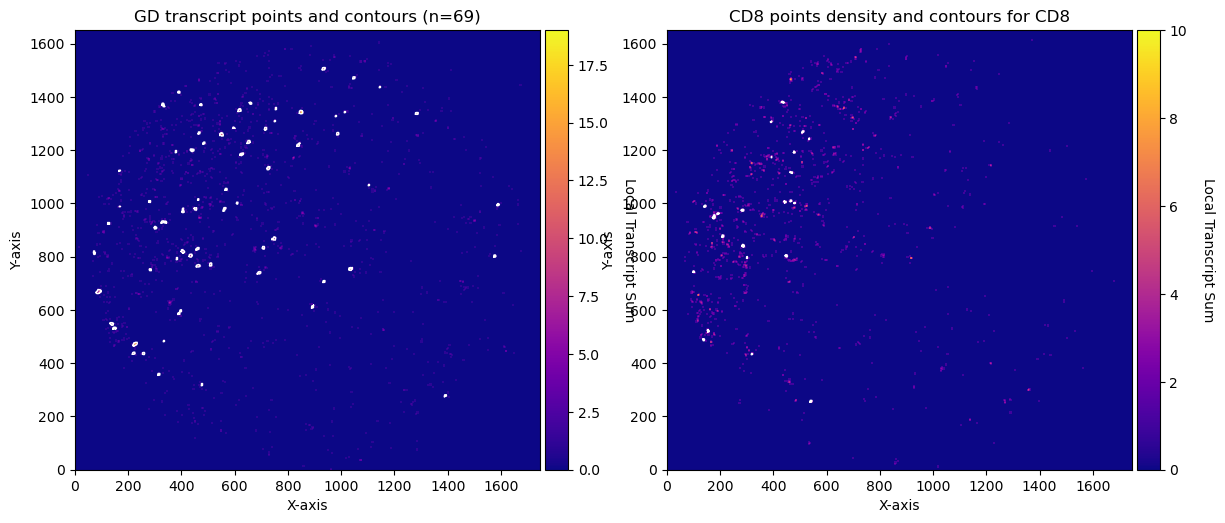

total contours found  23
 Completed ROI001

Processing ROI002...
  Image dimensions: 1690 x 1769
  Total transcripts: 957463


2026-03-14 12:48:50,407 - gridgene.contours.tum - INFO - Initialized GetContour
2026-03-14 12:48:50,464 - gridgene.contours.tum - INFO - get_conv_sum took 0.0565 seconds
2026-03-14 12:48:50,521 - gridgene.contours.tum - INFO - Number of contours after filtering no counts: 2
2026-03-14 12:48:50,521 - gridgene.contours.tum - INFO - contours_from_sum took 0.0568 seconds
2026-03-14 12:48:50,522 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks


  GD transcripts: 1457
  GD array sum: 1455.0
  AB transcripts: 8271


2026-03-14 12:48:50,953 - contour_logger - INFO - Initialized GetContour
2026-03-14 12:48:51,017 - contour_logger - INFO - get_conv_sum took 0.0633 seconds
2026-03-14 12:48:51,066 - contour_logger - INFO - Number of contours after filtering no counts: 66
2026-03-14 12:48:51,067 - contour_logger - INFO - contours_from_sum took 0.0499 seconds


  CD8 transcripts: 1838
  CD8 array sum: 1829.0

  Processing GD contours...
    Contours after density threshold: 66


...

    Contours after TRBC>=1 filter: 33


2026-03-14 12:48:53,563 - contour_logger - INFO - Excluding contour 32. ab count 2.00 ≤ gd count 2.00
2026-03-14 12:48:53,563 - contour_logger - INFO - Contours remaining after gene comparison: 32


    Contours after ab>gd filter: 32


2026-03-14 12:48:53,880 - contour_logger - INFO - Contours remaining after gene comparison: 32
2026-03-14 12:48:53,881 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks
2026-03-14 12:48:53,881 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.
2026-03-14 12:48:53,882 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.


    Final CD8 contours: 32


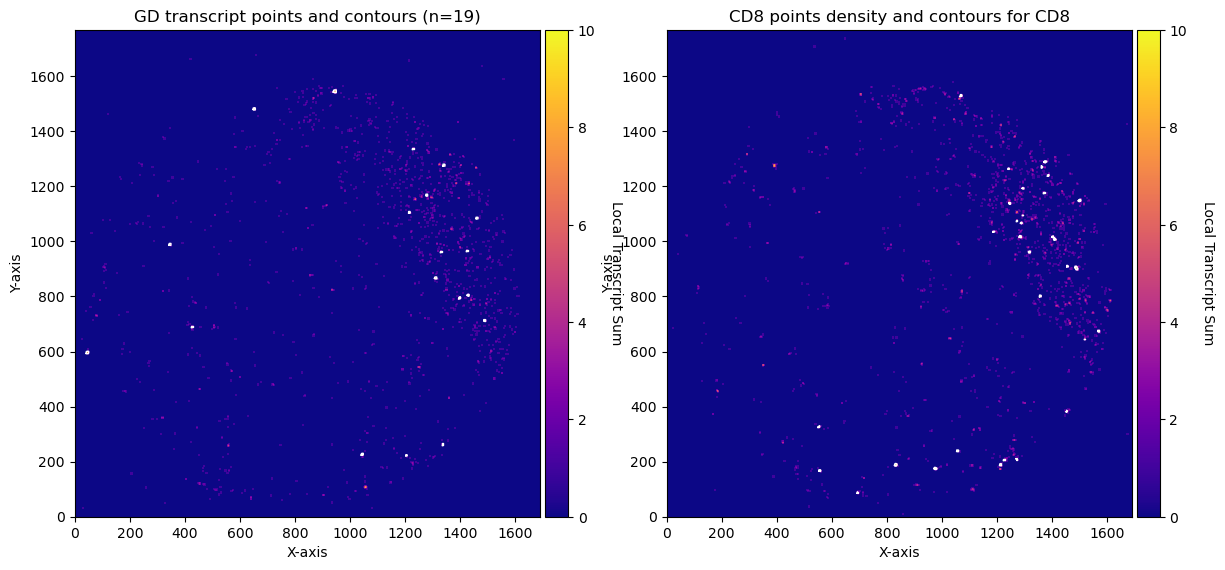

total contours found  32
 Completed ROI002

Processing ROI003...
  Image dimensions: 1793 x 1888
  Total transcripts: 4100005


2026-03-14 12:49:00,160 - gridgene.contours.tum - INFO - Initialized GetContour
2026-03-14 12:49:00,225 - gridgene.contours.tum - INFO - get_conv_sum took 0.0647 seconds
2026-03-14 12:49:00,309 - gridgene.contours.tum - INFO - Number of contours after filtering no counts: 68
2026-03-14 12:49:00,309 - gridgene.contours.tum - INFO - contours_from_sum took 0.0837 seconds
2026-03-14 12:49:00,310 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks


  GD transcripts: 2621
  GD array sum: 2608.0
  AB transcripts: 17091


2026-03-14 12:49:01,240 - contour_logger - INFO - Initialized GetContour
2026-03-14 12:49:01,314 - contour_logger - INFO - get_conv_sum took 0.0739 seconds


  CD8 transcripts: 4563
  CD8 array sum: 4518.0

  Processing GD contours...


...

    Contours after TRBC>=1 filter: 185


2026-03-14 12:49:08,143 - contour_logger - INFO - Excluding contour 16. ab count 3.00 ≤ gd count 3.00
2026-03-14 12:49:08,463 - contour_logger - INFO - Excluding contour 48. ab count 3.00 ≤ gd count 4.00
2026-03-14 12:49:08,566 - contour_logger - INFO - Excluding contour 58. ab count 2.00 ≤ gd count 3.00
2026-03-14 12:49:08,697 - contour_logger - INFO - Excluding contour 71. ab count 2.00 ≤ gd count 2.00
2026-03-14 12:49:09,208 - contour_logger - INFO - Excluding contour 124. ab count 3.00 ≤ gd count 3.00
2026-03-14 12:49:09,791 - contour_logger - INFO - Contours remaining after gene comparison: 180


    Contours after ab>gd filter: 180


2026-03-14 12:49:10,103 - contour_logger - INFO - Excluding contour 26. CD8 count 1.00 ≤ CD4 count 1.00
2026-03-14 12:49:11,626 - contour_logger - INFO - Contours remaining after gene comparison: 179
2026-03-14 12:49:11,627 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks
2026-03-14 12:49:11,627 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.
2026-03-14 12:49:11,628 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.


    Final CD8 contours: 179


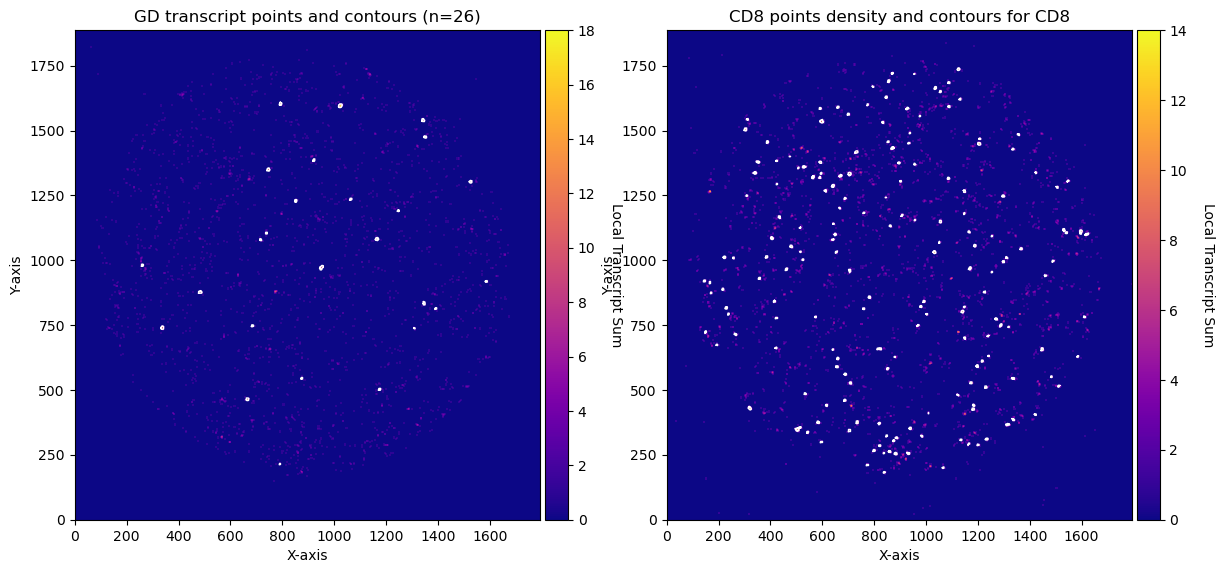

total contours found  179
 Completed ROI003


In [21]:
def gridgene_pipeline(file_csv, plot=False):
    """Run GRIDGENE pipeline with diagnostics"""   
    # Load and prepare data
    df_total = pd.read_csv(file_csv)
    df_total = df_total[['x_location', 'y_location', 'feature_name']]
    df_total = df_total.rename(columns={'feature_name': 'target'})
    df_total = df_total[~df_total['target'].str.contains('System|egative')]
    df_total['X'] = df_total['x_location'] - min(df_total['x_location'])
    df_total['Y'] = df_total['y_location'] - min(df_total['y_location'])
    
    n_genes = len(df_total['target'].unique())
    height = int(max(df_total['X'])) + 1
    width = int(max(df_total['Y'])) + 1
    
    print(f"  Image dimensions: {height} x {width}")
    print(f"  Total transcripts: {len(df_total)}")
    
    target_dict_total = {target: index for index, target in enumerate(df_total['target'].unique())}
    
    # Create array
    array_total = ga.transform_df_to_array(
        df=df_total, 
        target_dict=target_dict_total, 
        array_shape=(height, width, len(target_dict_total))
    ).astype(np.int8)
    
    # for tum just for reference:
    # Subset for tumor markers
    df_subset_tum, array_subset_tum, target_indices_subset_tum = ga.get_subset_arrays(
        df_total, array_total, target_dict_total,
        target_list=target_tum, target_col='target'
    )
    
    # Tumor contours
    CTum = contours.ConvolutionContours(array_subset_tum, contour_name='tum')
    CTum.get_conv_sum(kernel_size=kernel_size_tum, kernel_shape='square')
    CTum.contours_from_sum(
        density_threshold=density_th_tum,
        min_area_threshold=min_area_th_tum,
        directionality='higher'
    )
    # Create masks
    GM = get_masks.GetMasks(image_shape=(height, width))
    mask_tum = GM.create_mask(CTum.contours)
      
    # GD subset
    df_subset_gd, array_subset_gd, target_indices_subset_gd = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=target_gd, target_col='target'
    )
    print(f"  GD transcripts: {len(df_subset_gd)}")
    print(f"  GD array sum: {array_subset_gd.sum()}")
    
    # AB subset
    df_subset_ab, array_subset_ab, target_indices_subset_ab = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=target_ab, target_col='target'
    )
    print(f"  AB transcripts: {len(df_subset_ab)}")
    
    # Other subsets
    df_subset_g, array_subset_g, target_indices_subset_g = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=['TRGC1', 'TRGC2'], target_col='target'
    )
    
    df_subset_d, array_subset_d, target_indices_subset_d = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=['TRDC'], target_col='target'
    )
    
    df_subset_TRAC_gene, array_subset_TRAC_gene, target_indices_subset_TRAC_gene = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=['TRAC'], target_col='target'
    )
    
    df_subset_TRBC_gene, array_subset_TRBC_gene, target_indices_subset_TRBC_gene = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=['TRBC1', 'TRBC2'], target_col='target'
    )
    
    df_subset_cd8_gene, array_subset_cd8_gene, target_indices_subset_cd8_gene = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=['CD8A', 'CD8B'], target_col='target'
    )
    print(f"  CD8 transcripts: {len(df_subset_cd8_gene)}")
    print(f"  CD8 array sum: {array_subset_cd8_gene.sum()}")
    
    df_subset_cd4_gene, array_subset_cd4_gene, target_indices_subset_cd4_gene = ga.get_subset_arrays(
        df_total, array_total, target_dict_total, target_list=['CD4'], target_col='target'
    )

    ### FOR GD 
    print("\n  Processing GD contours...")
    CGD = contours.ConvolutionContours(array_subset_gd, contour_name='GD', logger=logger)
    CGD.get_conv_sum(kernel_size=kernel_size_gd, kernel_shape='square')
    
    CGD.contours_from_sum(density_threshold=density_th_gd, min_area_threshold=min_area_th_gd, directionality='higher')
    print(f"    Contours after density threshold: {len(CGD.contours)}")
    
    CGD.filter_contours_by_gene_comparison(gene_array1=array_subset_gd, gene_array2=array_subset_ab,
                                           gene_name1="gd", gene_name2="ab")
    print(f"    Contours after gd>ab filter: {len(CGD.contours)}")
    
    CGD.filter_contours_by_gene_threshold(gene_array=array_subset_d.squeeze(), threshold=1, gene_name='TRDC')
    print(f"    Contours after TRDC>=1 filter: {len(CGD.contours)}")
    
    CGD.filter_contours_by_gene_threshold(gene_array=np.sum(array_subset_g, axis=-1), threshold=1, gene_name='TRGC1_2')
    print(f"    Final GD contours: {len(CGD.contours)}")
    
    ### FOR CD8
    print("\n  Processing CD8 contours...")
    CCD8 = contours.ConvolutionContours(array_subset_cd8_gene, contour_name='CD8', logger=logger)
    CCD8.get_conv_sum(kernel_size=kernel_size_cd8, kernel_shape='square')
    
    CCD8.contours_from_sum(density_threshold=density_th_cd8, min_area_threshold=min_area_th_cd8, directionality='higher')
    print(f"    Contours after density threshold: {len(CCD8.contours)}")
    
    CCD8.filter_contours_by_gene_threshold(gene_array=np.sum(array_subset_cd8_gene, axis=-1).squeeze(), threshold=1, gene_name='CD8')
    print(f"    Contours after CD8>=1 filter: {len(CCD8.contours)}")
    
    CCD8.filter_contours_by_gene_threshold(gene_array=array_subset_TRAC_gene.squeeze(), threshold=1, gene_name='TRAC')
    print(f"    Contours after TRAC>=1 filter: {len(CCD8.contours)}")
    
    CCD8.filter_contours_by_gene_threshold(gene_array=np.sum(array_subset_TRBC_gene, axis=-1), threshold=1, gene_name='TRBC1_2')
    print(f"    Contours after TRBC>=1 filter: {len(CCD8.contours)}")
    
    CCD8.filter_contours_by_gene_comparison(gene_array1=array_subset_ab, gene_array2=array_subset_gd,
                                           gene_name1="ab", gene_name2="gd")
    print(f"    Contours after ab>gd filter: {len(CCD8.contours)}")
    
    CCD8.filter_contours_by_gene_comparison(gene_array1=array_subset_cd8_gene, gene_array2=array_subset_cd4_gene,
                                           gene_name1="CD8", gene_name2="CD4")
    print(f"    Final CD8 contours: {len(CCD8.contours)}")
    
    # Create masks
    GM = get_masks.GetMasks(image_shape=(height, width))
    SA = get_masks.SingleClassObjectAnalysis(GM, contours_object=CGD.contours)
    SA.get_mask_objects(exclude_masks=None)
    mask_gd = SA.mask_object_SA
    SA = get_masks.SingleClassObjectAnalysis(GM, contours_object=CCD8.contours)
    SA.get_mask_objects(exclude_masks=None)
    mask_cd8 = SA.mask_object_SA

    
    # Plot diagnostics
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    CGD.plot_conv_sum(cmap='plasma', c_countour='white', path=None, ax=axs[0])
    axs[0].set_title(f'GD transcript points and contours (n={len(CGD.contours)})')
    CCD8.plot_conv_sum(cmap='plasma', c_countour='white', path=None, ax=axs[1])
    axs[1].set_title('CD8 points density and contours for CD8')

    plt.show()

    print('total contours found ', len(CCD8.contours))
    
    basename = os.path.basename(file_csv)
    fov_match = re.search(r'FOV\d{3}', basename)
    fov = fov_match.group(0) if fov_match else basename.split('_')[0]

    return {
        'gd': mask_gd,
        'cd8': mask_cd8,
        'tum':mask_tum,
        'height': height,
        'width': width,
        'filename': file_csv,
        'n_gd_contours': len(CGD.contours),
        'n_cd8_contours': len(CCD8.contours)
    }


############# RUN GRIDGENE ###################

density_th_gd = 2
min_area_th_gd = 6
kernel_size_gd = 8

density_th_cd8 = 3
min_area_th_cd8 = 6
kernel_size_cd8 = 8
target_gd = ['TRGC1', 'TRGC2', 'TRDC']
target_ab = ['TRBC1', 'TRBC2','TRAC']

target_cd8 = ['CD8A','CD8B', 'TRBC1', 'TRBC2', 'TRAC']
target_cd4 = ['CD4']

xenium_results = {}
for fov_name, paths in roi_data.items():
    print(f"\nProcessing {fov_name}...")
    
    result = gridgene_pipeline(
        paths['xenium_path'],
        plot=True
    )

    result['fov'] = fov_name
    
    xenium_results[fov_name] = result
    print(f" Completed {fov_name}")

## 3. Compare gridgene with IMC masks

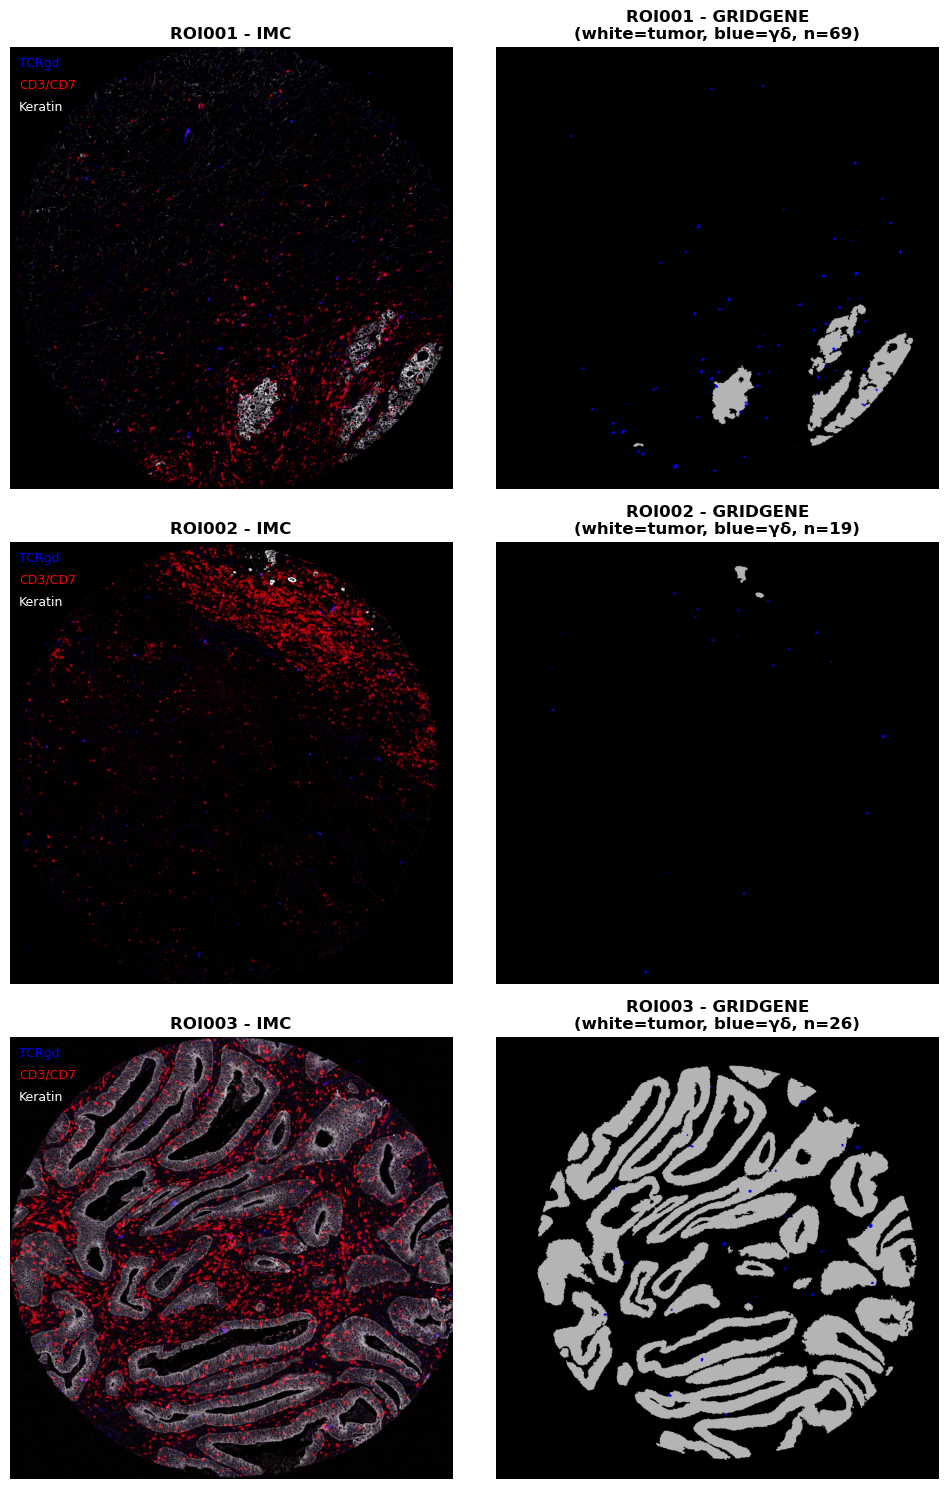

In [26]:
OUTPUT_DIR = 'figures/xenium'
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig, axes = plt.subplots(n, 2, figsize=(10, 5*n))

for idx, roi_name in enumerate(roi_names):
    img = tifffile.imread(os.path.join(imc_path, imc_files[roi_name]))
    img = (img / 65535 * 255).astype(np.uint8)
    imc_shape = img.shape[:2]

    # Transform masks
    tum_mask = np.flipud(xenium_results[roi_name]['tum'])
    gd_mask  = np.flipud(xenium_results[roi_name]['gd'])

    # Resize if needed
    if tum_mask.shape != imc_shape:
        tum_mask = cv2.resize(tum_mask.astype(np.uint8), (imc_shape[1], imc_shape[0]), interpolation=cv2.INTER_NEAREST)
        gd_mask  = cv2.resize(gd_mask.astype(np.uint8),  (imc_shape[1], imc_shape[0]), interpolation=cv2.INTER_NEAREST)

    # Build overlay: white=tumor, blue=gd, black=background
    overlay = np.zeros((*imc_shape, 3), dtype=np.uint8)
    overlay[tum_mask == 1] = (180, 180, 180) # white = tumor. now grey
    overlay[gd_mask == 1]  = (0, 0, 255)      # blue = gd

    # Column 1: IMC
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f'{roi_name} - IMC', fontweight='bold')
    axes[idx, 0].text(0.02, 0.98, 'TCRgd',   color='blue',  transform=axes[idx, 0].transAxes, fontsize=9, va='top')
    axes[idx, 0].text(0.02, 0.93, 'CD3/CD7', color='red',   transform=axes[idx, 0].transAxes, fontsize=9, va='top')
    axes[idx, 0].text(0.02, 0.88, 'Keratin',  color='white', transform=axes[idx, 0].transAxes, fontsize=9, va='top')
    axes[idx, 0].axis('off')

    # Column 2: GRIDGENE overlay
    axes[idx, 1].imshow(overlay)
    axes[idx, 1].set_title(f'{roi_name} - GRIDGENE\n(white=tumor, blue=γδ, n={xenium_results[roi_name]["n_gd_contours"]})', fontweight='bold')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xenium_gd_gridgene.png', dpi=300, bbox_inches='tight')
plt.show()